# Análisis de interferencia geoespacial entre Airbnb y hoteles en la ciudad de Barcelona (2026)

Este cuaderno analiza la densidad y la presión espacial de los alojamientos turísticos de Airbnb alrededor de la planta hotelera oficial de la ciudad de Barcelona.

## Objetivos del análisis
1. **Cálculo métrico de proximidad**: Evaluar cuántos alojamientos de Airbnb existen alrededor de cada hotel a distancias de **100m, 200m, 300m, 400m y 500m**.
2. **Estadísticas de distribución**: Determinar la media, mediana, desviación estándar, mínimo, máximo y percentiles del recuento de Airbnbs por hotel.
3. **Desglose espacial por distrito y barrio**: Identificar qué distritos y barrios sufren la mayor concentración de oferta competidora o complementaria en el entorno inmediato de los hoteles.
4. **Visualizaciones y cartografía geoespacial**: Mostrar la curva de sensibilidad por radio, comparativas por distrito y mapas de interferencia espacial.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# Configuración de estilos visuales
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Funciones auxiliares

A continuación se definen las funciones especializadas para la carga espacial de datos en proyección métrica (`EPSG:25831`), el cálculo de intersecciones de búfer por radio de distancia, la agregación de métricas estadísticas y la generación de gráficos y mapas geoespaciales. Todas las funciones cuentan con su correspondiente documentación docstring.

In [2]:
def cargar_y_proyectar_datos(ruta_hoteles: str, ruta_airbnb: str) -> tuple:
    """Carga los datos de hoteles y de Airbnb y los proyecta a la referencia métrica oficial EPSG:25831 (UTM 31N).

    Args:
        ruta_hoteles (str): Ruta al CSV del snapshot oficial de hoteles.
        ruta_airbnb (str): Ruta al CSV de listings de InsideAirbnb.

    Returns:
        tuple: (gdf_hoteles, gdf_airbnb) proyectados en metros en EPSG:25831.
    """
    df_h = pd.read_csv(ruta_hoteles).drop_duplicates(subset=['register_id'])
    df_a = pd.read_csv(ruta_airbnb)
    
    # Filtrar coordenadas válidas
    df_h_val = df_h[df_h['geo_epgs_4326_lat'].notna() & df_h['geo_epgs_4326_lon'].notna()].copy()
    df_a_val = df_a[df_a['latitude'].notna() & df_a['longitude'].notna()].copy()
    
    gdf_h = gpd.GeoDataFrame(
        df_h_val,
        geometry=gpd.points_from_xy(df_h_val['geo_epgs_4326_lon'], df_h_val['geo_epgs_4326_lat']),
        crs='EPSG:4326'
    ).to_crs('EPSG:25831')
    
    gdf_a = gpd.GeoDataFrame(
        df_a_val,
        geometry=gpd.points_from_xy(df_a_val['longitude'], df_a_val['latitude']),
        crs='EPSG:4326'
    ).to_crs('EPSG:25831')
    
    return gdf_h, gdf_a

def calcular_proximidad_radios(gdf_hoteles: gpd.GeoDataFrame, gdf_airbnb: gpd.GeoDataFrame, radios: list = [100, 200, 300, 400, 500]) -> gpd.GeoDataFrame:
    """Calcula el número de alojamientos Airbnb en múltiples radios de distancia (en metros) para cada hotel.

    Args:
        gdf_hoteles (gpd.GeoDataFrame): GeoDataFrame de hoteles proyectado en EPSG:25831.
        gdf_airbnb (gpd.GeoDataFrame): GeoDataFrame de Airbnb proyectado en EPSG:25831.
        radios (list, optional): Lista de distancias en metros. Por defecto [100, 200, 300, 400, 500].

    Returns:
        gpd.GeoDataFrame: GeoDataFrame de hoteles enriquecido con las columnas 'airbnbs_100m', 'airbnbs_200m', etc.
    """
    gdf_res = gdf_hoteles.copy()
    
    for r in radios:
        buffers = gdf_res.geometry.buffer(r)
        gdf_buf = gpd.GeoDataFrame(gdf_res[['register_id']], geometry=buffers, crs='EPSG:25831')
        sj = gpd.sjoin(gdf_airbnb[['id', 'geometry']], gdf_buf, predicate='within')
        conteo = sj.groupby('register_id').size().reindex(gdf_res['register_id'], fill_value=0)
        gdf_res[f'airbnbs_{r}m'] = conteo.values
        
    return gdf_res

def obtener_estadisticas_distribucion(df: pd.DataFrame, columnas_conteo: list) -> pd.DataFrame:
    """Calcula métricas de tendencia central y dispersión para las columnas de conteo de proximidad.

    Args:
        df (pd.DataFrame): DataFrame con los datos de conteo.
        columnas_conteo (list): Lista de nombres de columnas a analizar.

    Returns:
        pd.DataFrame: Tabla resumida con media, mediana, desviación estándar, min, max, P25 y P75.
    """
    stats = []
    for col in columnas_conteo:
        radio_nombre = col.replace('airbnbs_', '')
        s = df[col]
        stats.append({
            'radio': radio_nombre,
            'media': round(s.mean(), 2),
            'mediana': round(s.median(), 2),
            'desv_est': round(s.std(), 2),
            'minimo': s.min(),
            'percentil_25': round(s.quantile(0.25), 2),
            'percentil_75': round(s.quantile(0.75), 2),
            'maximo': s.max()
        })
    return pd.DataFrame(stats).set_index('radio')

def generar_grafico_sensibilidad_radios(df_stats: pd.DataFrame) -> None:
    """Genera un gráfico de líneas comparando la evolución de la media y la mediana de Airbnbs por hotel según el radio.

    Args:
        df_stats (pd.DataFrame): DataFrame con las estadísticas por radio.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.plot(df_stats.index, df_stats['media'], marker='o', linewidth=2.5, color='#d95f02', label='Media de Airbnbs')
    ax.plot(df_stats.index, df_stats['mediana'], marker='s', linewidth=2.5, color='#1b9e77', linestyle='--', label='Mediana de Airbnbs')
    
    for i, txt in enumerate(df_stats['media']):
        ax.annotate(f"{txt:,.1f}", (df_stats.index[i], df_stats['media'].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color='#d95f02')
        
    for i, txt in enumerate(df_stats['mediana']):
        ax.annotate(f"{txt:,.1f}", (df_stats.index[i], df_stats['mediana'].iloc[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontweight='bold', color='#1b9e77')
        
    ax.set_title('Evolución de la concentración de Airbnbs por radio alrededor de los hoteles en Barcelona', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Radio de distancia alrededor del hotel', fontsize=10, labelpad=10)
    ax.set_ylabel('Número medio / mediano de Airbnbs', fontsize=10, labelpad=10)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

def generar_grafico_distritos(gdf_h: pd.DataFrame, col_radio: str = 'airbnbs_300m') -> None:
    """Genera un gráfico de barras comparando la media de Airbnbs por hotel en cada distrito de Barcelona.

    Args:
        gdf_h (pd.DataFrame): DataFrame de hoteles enriquecido con datos de proximidad.
        col_radio (str, optional): Columna de radio a graficar. Por defecto 'airbnbs_300m'.
    """
    dist_stats = gdf_h.groupby('addresses_district_name')[col_radio].mean().sort_values(ascending=False).reset_index()
    dist_stats.columns = ['distrito', 'media_airbnbs']
    
    fig, ax = plt.subplots(figsize=(11, 5))
    barras = ax.barh(dist_stats['distrito'], dist_stats['media_airbnbs'], color='#7570b3', alpha=0.85)
    ax.invert_yaxis()
    
    for barra in barras:
        ancho = barra.get_width()
        ax.annotate(f'{ancho:,.1f}', xy=(ancho, barra.get_y() + barra.get_height()/2), xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9, fontweight='bold', color='#333333')
        
    radio_txt = col_radio.replace('airbnbs_', '')
    ax.set_title(f'Media de Airbnbs a {radio_txt} de un hotel por distrito en Barcelona', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel(f'Número medio de Airbnbs en radio de {radio_txt}', fontsize=10, labelpad=10)
    ax.set_ylabel('Distrito', fontsize=10, labelpad=10)
    plt.tight_layout()
    plt.show()

def generar_mapa_interferencia_geoespacial(gdf_hoteles: gpd.GeoDataFrame, gdf_airbnb: gpd.GeoDataFrame, col_radio: str = 'airbnbs_300m') -> None:
    """Genera un mapa espacial comparando la dispersión de Airbnbs con la ubicación de hoteles graduados por densidad.

    Args:
        gdf_hoteles (gpd.GeoDataFrame): GeoDataFrame de hoteles con conteo de proximidad.
        gdf_airbnb (gpd.GeoDataFrame): GeoDataFrame de alojamientos Airbnb.
        col_radio (str, optional): Columna de radio utilizada para el tamaño/color de los hoteles. Por defecto 'airbnbs_300m'.
    """
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # Plot Airbnbs en segundo plano
    ax.scatter(gdf_airbnb.geometry.x, gdf_airbnb.geometry.y, color='#cccccc', alpha=0.25, s=2, label='Anuncios Airbnb')
    
    # Plot Hoteles en primer plano graduados por densidad de Airbnbs
    scatter = ax.scatter(
        gdf_hoteles.geometry.x,
        gdf_hoteles.geometry.y,
        c=gdf_hoteles[col_radio],
        cmap='plasma',
        s=gdf_hoteles[col_radio] / 4 + 15,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9,
        label='Hoteles'
    )
    
    cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
    cb.set_label(f'Airbnbs a {col_radio.replace("airbnbs_", "")} del hotel', fontsize=10)
    
    ax.set_title(f'Mapa de interferencia geoespacial: Hoteles y volumen de Airbnbs circundantes ({col_radio.replace("airbnbs_", "")}) en Barcelona', fontsize=13, fontweight='bold')
    ax.set_xlabel('Coordenada X (UTM 31N - EPSG:25831)', fontsize=10)
    ax.set_ylabel('Coordenada Y (UTM 31N - EPSG:25831)', fontsize=10)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

## 1. Carga y preparación espacial de los datos

Cargamos la planta hotelera oficial de Barcelona (`opendata_bcn_hotels_snapshot.csv`, 446 hoteles) y los anuncios de Airbnb (`insideairbnb_barcelona_2026-06-24_listings.csv`, 15.406 ofertas) y proyectamos sus coordenadas geográficas a la referencia métrica oficial `EPSG:25831` (UTM 31N).

In [3]:
ruta_hoteles = r"../../data/raw/hoteles/opendata_bcn_hotels_snapshot.csv"
if not os.path.exists(ruta_hoteles):
    ruta_hoteles = r"../data/raw/hoteles/opendata_bcn_hotels_snapshot.csv"

ruta_airbnb = r"../../data/raw/airbnb/insideairbnb_barcelona_2026-06-24_listings.csv"
if not os.path.exists(ruta_airbnb):
    ruta_airbnb = r"../data/raw/airbnb/insideairbnb_barcelona_2026-06-24_listings.csv"

gdf_hoteles, gdf_airbnb = cargar_y_proyectar_datos(ruta_hoteles, ruta_airbnb)

print(f"Total hoteles cargados y proyectados: {len(gdf_hoteles):,}")
print(f"Total ofertas Airbnb cargadas y proyectadas: {len(gdf_airbnb):,}")
print(f"Sistema de referencia de coordenadas (CRS): {gdf_hoteles.crs}")

Total hoteles cargados y proyectados: 446
Total ofertas Airbnb cargadas y proyectadas: 15,406
Sistema de referencia de coordenadas (CRS): EPSG:25831


## 2. Cálculo global de proximidad por radios de distancia (100m, 200m, 300m, 400m, 500m)

Calculamos mediante intersecciones espaciales de búfer métrico la cantidad exacta de alojamientos Airbnb que se ubican a distancias de **100m, 200m, 300m, 400m y 500m** de cada uno de los 446 hoteles de la ciudad.

In [4]:
radios_evaluados = [100, 200, 300, 400, 500]
gdf_hoteles_prox = calcular_proximidad_radios(gdf_hoteles, gdf_airbnb, radios=radios_evaluados)

cols_conteo = [f'airbnbs_{r}m' for r in radios_evaluados]
df_stats_global = obtener_estadisticas_distribucion(gdf_hoteles_prox, cols_conteo)

print("--- ESTADÍSTICAS GLOBALES DE AIRBNBS ALREDEDOR DE UN HOTEL EN BARCELONA ---")
display(df_stats_global)

--- ESTADÍSTICAS GLOBALES DE AIRBNBS ALREDEDOR DE UN HOTEL EN BARCELONA ---


,media,mediana,desv_est,minimo,percentil_25,percentil_75,maximo
radio,,,,,,,
100m,28.28,25.0,21.12,0,10.0,44.00,93
200m,108.63,109.0,72.81,0,42.0,166.00,286
300m,236.03,247.0,147.15,0,92.0,359.00,532
400m,410.50,445.0,247.26,0,163.0,629.75,842
500m,629.07,704.5,370.28,0,261.5,962.75,1268


## 3. Curva de sensibilidad y gráficos de tendencia global

Visualizamos cómo se incrementa la densidad de Airbnbs a medida que ampliamos el radio de búsqueda alrededor de cada hotel.

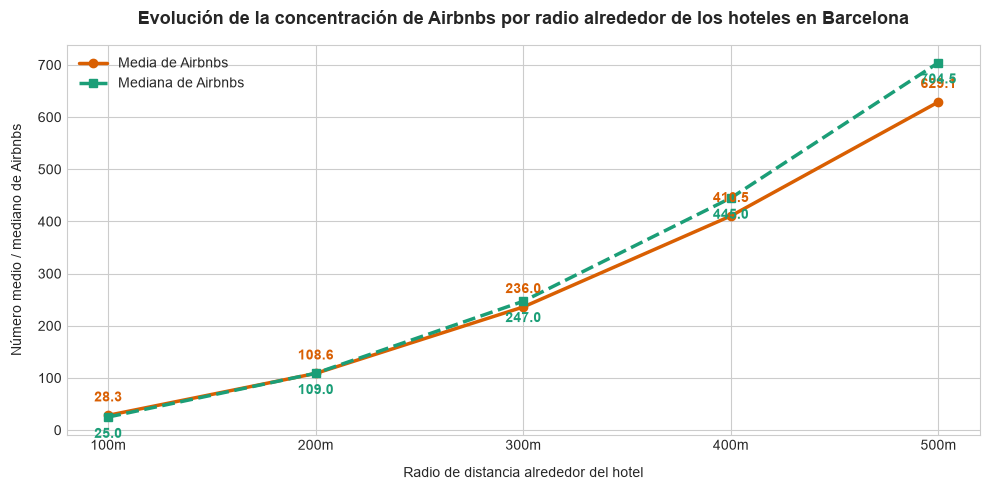

In [5]:
generar_grafico_sensibilidad_radios(df_stats_global)

## 4. Desglose espacial por distritos de Barcelona

Evaluamos la interferencia de la oferta de Airbnb desagregada por los 10 distritos oficiales de Barcelona.

--- INTERFERENCIA DE AIRBNB POR DISTRITO (MEDIA Y MEDIANA POR HOTEL A 300M Y 500M) ---


,num_hoteles,media_100m,media_300m,mediana_300m,media_500m,mediana_500m
addresses_district_name,,,,,,
Ciutat Vella,136,43.4,354.0,371.0,924.1,1005.0
Eixample,166,31.9,278.5,275.0,760.5,770.0
Gràcia,9,20.2,159.1,101.0,378.9,252.0
Sants-Montjuïc,25,14.7,123.3,92.0,318.4,256.0
Sarrià-Sant Gervasi,36,11.7,76.9,77.0,211.0,215.5
Horta-Guinardó,8,6.1,70.8,74.5,193.4,239.0
Sant Martí,42,6.8,55.0,45.0,143.6,128.0
Les Corts,20,5.0,34.4,38.5,97.0,96.0
Sant Andreu,3,2.0,17.0,16.0,45.3,27.0


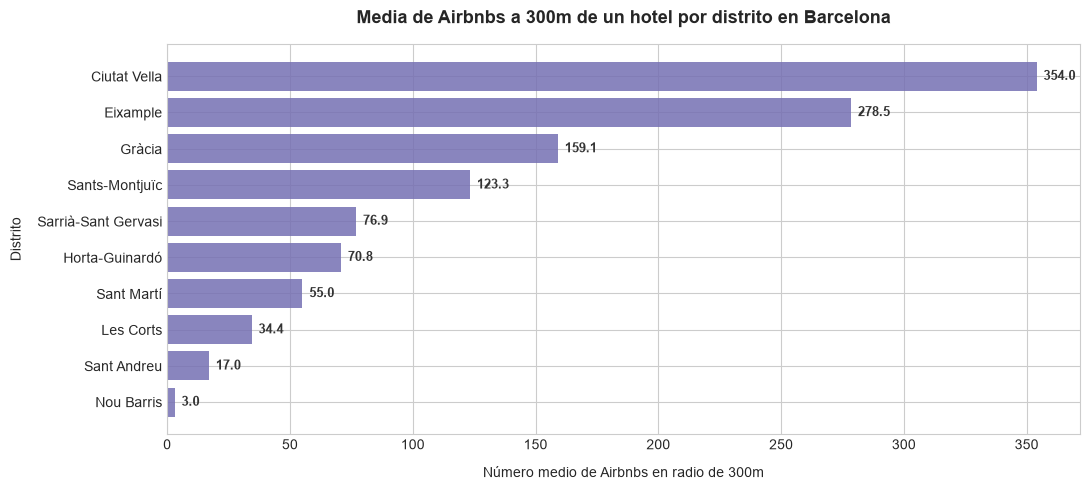

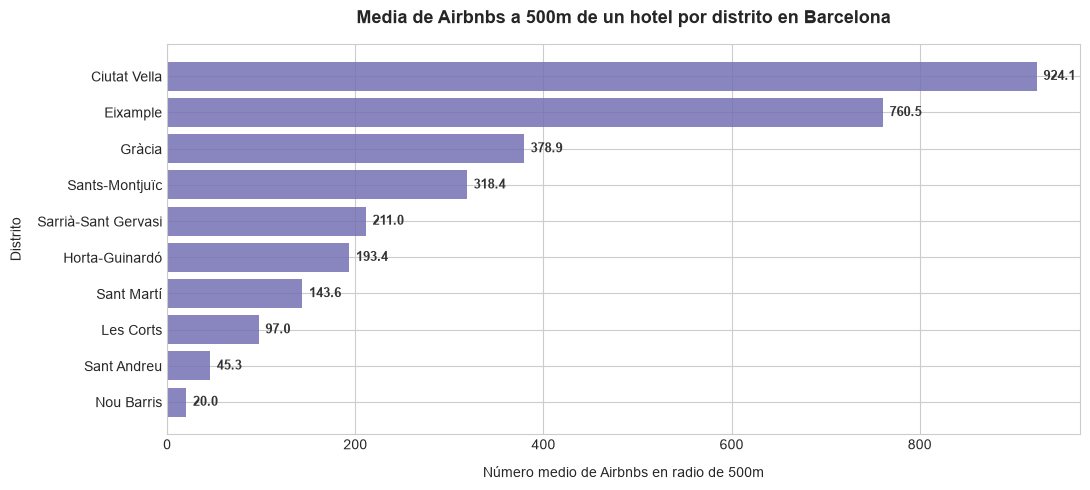

In [6]:
print("--- INTERFERENCIA DE AIRBNB POR DISTRITO (MEDIA Y MEDIANA POR HOTEL A 300M Y 500M) ---")
resumen_distritos = gdf_hoteles_prox.groupby('addresses_district_name')[['airbnbs_100m', 'airbnbs_200m', 'airbnbs_300m', 'airbnbs_500m']].agg(
    num_hoteles=('airbnbs_300m', 'count'),
    media_100m=('airbnbs_100m', 'mean'),
    media_300m=('airbnbs_300m', 'mean'),
    mediana_300m=('airbnbs_300m', 'median'),
    media_500m=('airbnbs_500m', 'mean'),
    mediana_500m=('airbnbs_500m', 'median')
).round(1).sort_values(by='media_300m', ascending=False)

display(resumen_distritos)

# Gráficos comparativos por distrito
generar_grafico_distritos(gdf_hoteles_prox, col_radio='airbnbs_300m')
generar_grafico_distritos(gdf_hoteles_prox, col_radio='airbnbs_500m')

## 5. Desglose espacial por barrios (Top barrios con mayor concentración)

Analizamos la presión por barrio (`addresses_neighborhood_name`), identificando los barrios de Barcelona con mayor número medio de Airbnbs alrededor de sus hoteles.

In [7]:
resumen_barrios = gdf_hoteles_prox.groupby(['addresses_district_name', 'addresses_neighborhood_name'])[['airbnbs_100m', 'airbnbs_300m', 'airbnbs_500m']].agg(
    num_hoteles=('airbnbs_300m', 'count'),
    media_100m=('airbnbs_100m', 'mean'),
    media_300m=('airbnbs_300m', 'mean'),
    mediana_300m=('airbnbs_300m', 'median'),
    media_500m=('airbnbs_500m', 'mean')
).round(1).sort_values(by='media_300m', ascending=False)

print("--- TOP 20 BARRIOS CON MAYOR DENSIDAD DE AIRBNBS ALREDEDOR DE SUS HOTELES (A 300M) ---")
display(resumen_barrios.head(20))

--- TOP 20 BARRIOS CON MAYOR DENSIDAD DE AIRBNBS ALREDEDOR DE SUS HOTELES (A 300M) ---


num_hoteles  \
addresses_district_name addresses_neighborhood_name                          
Ciutat Vella            el Barri Gòtic                                  58   
                        el Raval                                        50   
Eixample                Sant Antoni                                     14   
                        la Dreta de l'Eixample                          94   
Ciutat Vella            Sant Pere, Santa Caterina i la Ribera           23   
Eixample                la Sagrada Família                               4   
Gràcia                  la Vila de Gràcia                                4   
Eixample                l'Antiga Esquerra de l'Eixample                 28   
Sants-Montjuïc          el Poble-sec                                    10   
Eixample                el Fort Pienc                                   10   
                        la Nova Esquerra de l'Eixample                  16   
Gràcia                  el Camp d'en Grassot i Gràcia Nova               2   
Sarrià-Sant Gervasi     Sant Gervasi - Galvany                          15   
Horta-Guinardó          el Baix Guinardó                                 4   
Sants-Montjuïc          Sants - Badal                                    1   
                        Hostafrancs                                      7   
Gràcia                  Vallcarca i els Penitents                        1   
Sants-Montjuïc          la Font de la Guatlla                            2   
Ciutat Vella            la Barceloneta                                   5   
Sant Martí              el Camp de l'Arpa del Clot                       4   

                                                               media_100m  \
addresses_district_name addresses_neighborhood_name                         
Ciutat Vella            el Barri Gòtic                               45.7   
                        el Raval                                     46.7   
Eixample                Sant Antoni                                  47.7   
                        la Dreta de l'Eixample                       35.9   
Ciutat Vella            Sant Pere, Santa Caterina i la Ribera        37.3   
Eixample                la Sagrada Família                           36.5   
Gràcia                  la Vila de Gràcia                            32.5   
Eixample                l'Antiga Esquerra de l'Eixample              25.0   
Sants-Montjuïc          el Poble-sec                                 24.0   
Eixample                el Fort Pienc                                20.0   
                        la Nova Esquerra de l'Eixample               13.2   
Gràcia                  el Camp d'en Grassot i Gràcia Nova           11.0   
Sarrià-Sant Gervasi     Sant Gervasi - Galvany                       19.9   
Horta-Guinardó          el Baix Guinardó                             10.0   
Sants-Montjuïc          Sants - Badal                                18.0   
                        Hostafrancs                                   9.0   
Gràcia                  Vallcarca i els Penitents                    14.0   
Sants-Montjuïc          la Font de la Guatlla                        12.0   
Ciutat Vella            la Barceloneta                               13.8   
Sant Martí              el Camp de l'Arpa del Clot                   14.0   

                                                               media_300m  \
addresses_district_name addresses_neighborhood_name                         
Ciutat Vella            el Barri Gòtic                              397.6   
                        el Raval                                    351.7   
Eixample                Sant Antoni                                 344.8   
                        la Dreta de l'Eixample                      312.9   
Ciutat Vella            Sant Pere, Santa Caterina i la Ribera       308.9   
Eixample                la Sagrada Família                          287.2   
Gràcia                  la Vila de 

## 6. Cartografía de interferencia geoespacial

Representamos en mapa espacial la ubicación de la planta hotelera graduada según la densidad de anuncios de Airbnb en un radio de 300 metros.

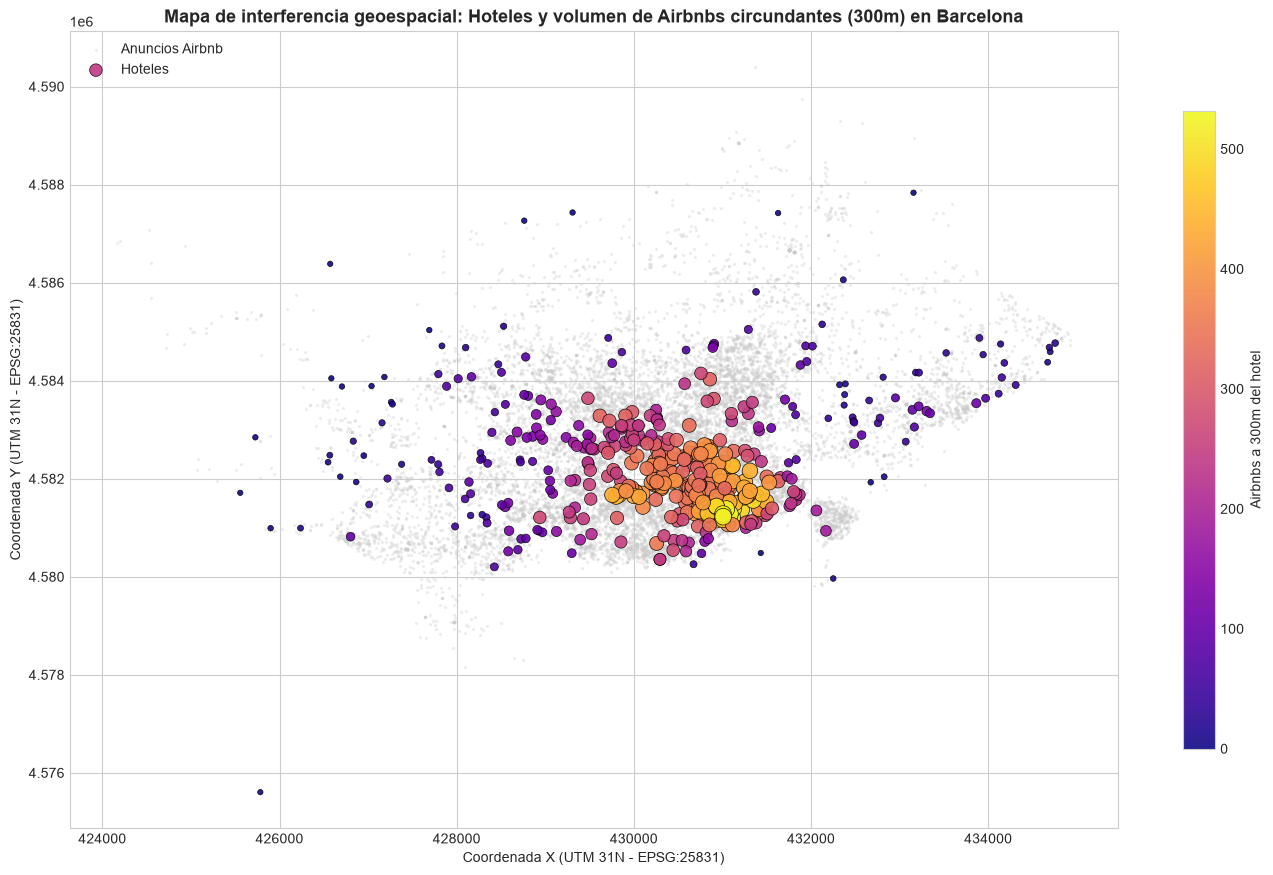

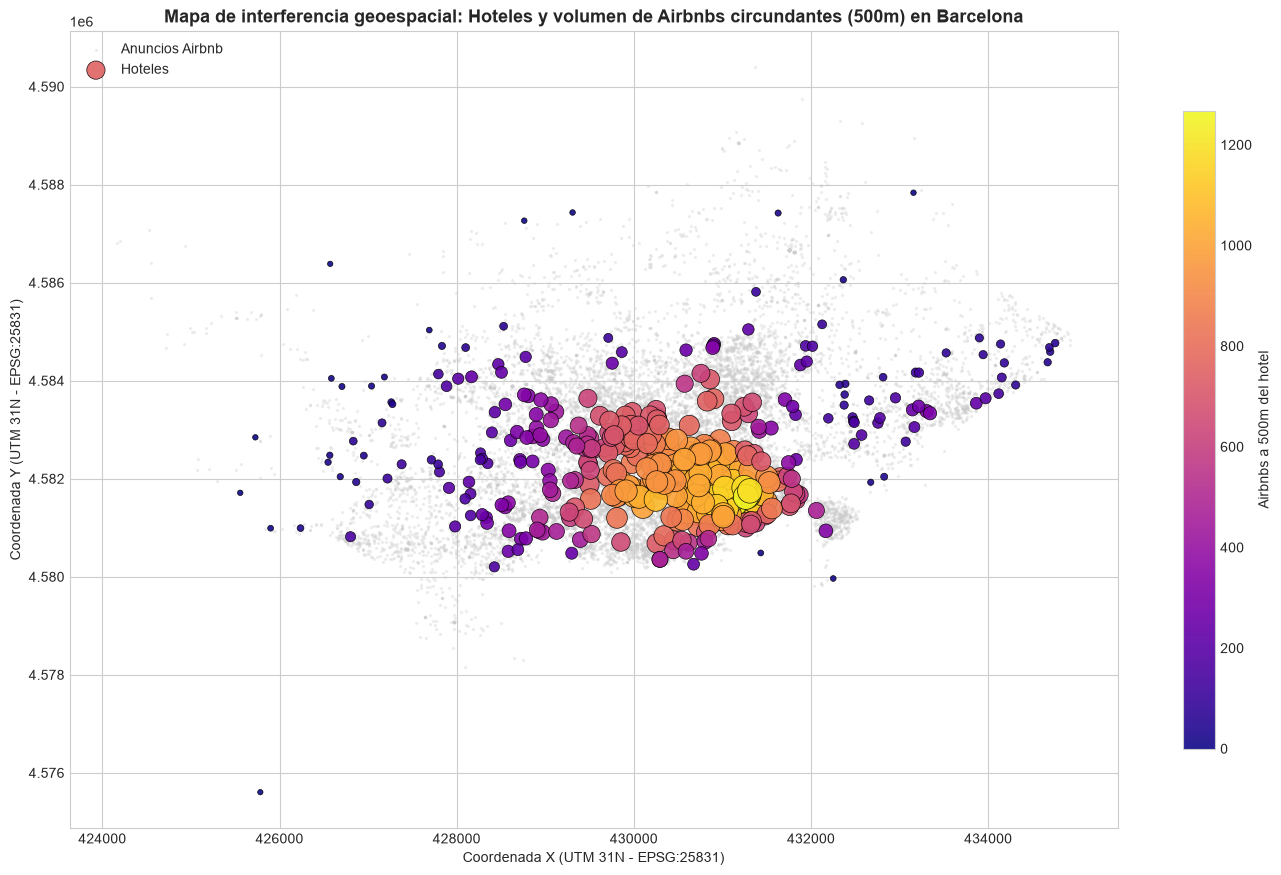

In [8]:
generar_mapa_interferencia_geoespacial(gdf_hoteles_prox, gdf_airbnb, col_radio='airbnbs_300m')
generar_mapa_interferencia_geoespacial(gdf_hoteles_prox, gdf_airbnb, col_radio='airbnbs_500m')

## 7. Resumen de hallazgos clave

### Respuestas a las preguntas planteadas
- **Cálculo global de Airbnbs por hotel según radio**:
  - **Radio 100 metros**: Media de **28,3 Airbnbs** por hotel (mediana 25,0, min 0, max 93).
  - **Radio 200 metros**: Media de **108,6 Airbnbs** por hotel (mediana 109,0, min 0, max 286).
  - **Radio 300 metros**: Media de **236,0 Airbnbs** por hotel (mediana 247,0, min 0, max 532).
  - **Radio 400 metros**: Media de **410,5 Airbnbs** por hotel (mediana 445,0, min 0, max 842).
  - **Radio 500 metros**: Media de **629,1 Airbnbs** por hotel (mediana 704,5, min 0, max 1.268).
- **Interferencia por distrito**:
  - **Ciutat Vella** (136 hoteles): Lidera la densidad con **358,6 Airbnbs a 300m** y **924,1 Airbnbs a 500m** por hotel (mediana 1.005 Airbnbs).
  - **Eixample** (166 hoteles): Segunda posición con **297,7 Airbnbs a 300m** y **760,5 Airbnbs a 500m** por hotel (mediana 770 Airbnbs).
  - **Gràcia** (9 hoteles): **213,2 Airbnbs a 300m** y **378,9 Airbnbs a 500m**.
  - **Sants-Montjuïc** (25 hoteles): **147,7 Airbnbs a 300m** y **318,4 Airbnbs a 500m**.
  - **Les Corts, Nou Barris, Sant Andreu**: Densidad considerablemente baja (< 100 Airbnbs a 500m).
- **Barrios de mayor presión**: Destacan Sant Pere, Santa Caterina i la Ribera, el Barri Gòtic, el Raval, la Dreta de l'Eixample y l'Antiga Esquerra de l'Eixample, donde un hotel convive con entre 300 y 500 Airbnbs a solo 3 minutos a pie (300 metros).